# Manta demo — banded targets, turnkey inference

This notebook shows the three layers that sit on top of the **banded (`.bhic.h5`) Hi-C store**:

1. **`io.banded.BandedHicFile`** — the observed Hi-C map + all metadata needed to plot it *autonomously*
   (no model, no fetcher). Any window is reconstructed on the fly from the stored diagonals.
2. **`nn.dataset.HiCDataset`** — samples eligible training/eval windows for a fold split (target + activations).
3. **`nn.inference.MantaInference`** — a trained `Manta` checkpoint + a MicroZoi activation fetcher →
   predict a map for a region, run wild-type vs mutant, and pull the matching observed map to compare.

All paths below point at the on-box demo bundle and the shared read-only mounts.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from manta_hic.io.banded import BandedHicFile
from manta_hic.nn.manta import CachedMicrozoiFetcher
from manta_hic.nn.inference import MantaInference
from manta_hic.nn.dataset import HiCDataset, train_val_test_folds

DEVICE = "cuda:0"
RES = 4096                       # trained-model / target resolution (bp per bin)
CACHE   = "../../data_ssd/microzoi_cache_hg38_all.h5"          # demo MicroZoi activation cache (hg38, chr1)
FASTA   = "/mnt/ro/max/manta/hg38.fa"          # needed only for mutation screens
MODEL   = "/net/levsha/scratch2/max/2024_manta_trained_models/4dn-diff_4096_all/saved_model.pth"
TARGET  = "/home/magus/data/hic/2024_manta_inputs/banded/4dn-diff_4096.bhic.h5"

# The demo cache only materialized run 0 (forward); real caches hold all 16 runs + both orientations, so
# there you would drop `run_idx=0` and use `n_runs=2` / `average_reverse=True` for deeper inference.
RUN_IDX = 0

## 1. The banded file is a self-describing, plottable Hi-C target

In [2]:
bf = BandedHicFile(TARGET)
print("genome", bf.genome, "| resolution", bf.resolution, "| channels", bf.n_channels)
print("channel (short) names:", bf.shortnames)
print("chromosomes with data:", bf.chroms[:5], "...", len(bf.chroms), "total")
print("Borzoi folds present:", bf.present_folds())

genome hg38 | resolution 4096 | channels 5
channel (short) names: ['4dn-diff-de', '4dn-diff-esc', '4dn-diff-hb', '4dn-diff-ihep', '4dn-diff-mhep']
chromosomes with data: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5'] ... 24 total
Borzoi folds present: [0, 1, 2, 3, 4, 5, 6, 7]


window chr1: 75321344 - 79515648 | eligible: True


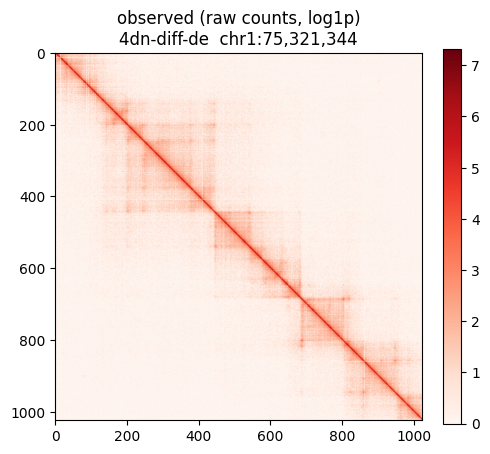

In [3]:
# Pick an eligible 1024-bin window on chr1 (inside the demo cache's coverage) and reconstruct the observed map.
N_BINS = 1024
starts = bf.eligible_starts("chr1", N_BINS)
starts = starts[(starts > 200) & (starts * bf.resolution < 180_000_000)]
start_bp = int(starts[len(starts) // 2]) * bf.resolution
print("window chr1:", start_bp, "-", start_bp + N_BINS * bf.resolution, "| eligible:", bf.is_eligible("chr1", start_bp, N_BINS))

hic, weight, exp = bf.get_window("chr1", start_bp, N_BINS)   # hic [C,N,N] raw counts, weight [C,N], exp [C,n_diag]
c = 0
plt.figure(figsize=(5, 5))
plt.imshow(np.log1p(hic[c]), cmap="Reds")
plt.title(f"observed (raw counts, log1p)\n{bf.shortnames[c]}  chr1:{start_bp:,}")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

## 2. Turnkey inference: predict, and compare to the observed map

`MantaInference` reads `output_channels` from the checkpoint and derives the tower height from `resolution`,
so you only supply the resolution. Pointing it at the banded `target` file unlocks `.target(...)` (observed
over expected, matching the training target) and the O(1) `.is_eligible(...)` guard.

In [4]:
fetcher = CachedMicrozoiFetcher(CACHE)
infer = MantaInference(MODEL, fetcher, resolution=RES, device=DEVICE, target=TARGET)
print("output channels:", infer.output_channels, "->", infer.channel_names)

pred = infer.predict("chr1", start_bp, run_idx=RUN_IDX)     # [C, N, N] predicted observed-over-expected
obs  = infer.target("chr1", start_bp)                       # [C, N, N] observed-over-expected (same window)
print("pred", tuple(pred.shape), "| obs", tuple(obs.shape))

output channels: 5 -> ['4dn-diff-de', '4dn-diff-esc', '4dn-diff-hb', '4dn-diff-ihep', '4dn-diff-mhep']


pred (5, 1024, 1024) | obs (5, 1024, 1024)


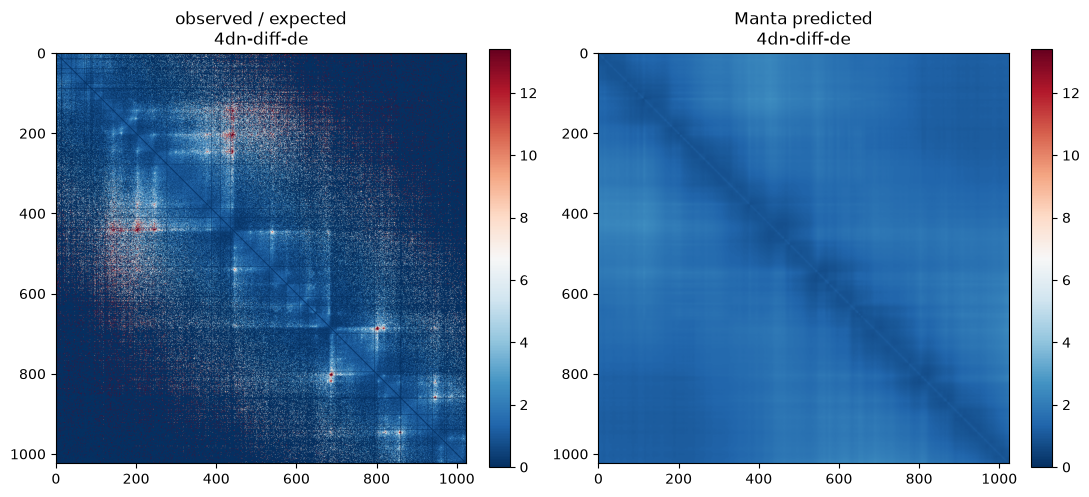

correlation of log(pred) vs log(obs): 0.642
(modest here: the demo cache is a different MicroZoi fold than this model was trained with.)


In [5]:
c = 0
P = pred[c].float().cpu().numpy(); O = obs[c].float().cpu().numpy()
vmax = np.nanpercentile(np.concatenate([P, O]), 99)
fig, ax = plt.subplots(1, 2, figsize=(11, 5.4))
for a, img, ttl in ((ax[0], O, "observed / expected"), (ax[1], P, "Manta predicted")):
    im = a.imshow(img, cmap="RdBu_r", vmin=0, vmax=vmax); a.set_title(f"{ttl}\n{infer.channel_names[c]}")
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

m = (O > 0) & (P > 0)
print("correlation of log(pred) vs log(obs):", round(float(np.corrcoef(np.log(P[m]), np.log(O[m]))[0, 1]), 3))
print("(modest here: the demo cache is a different MicroZoi fold than this model was trained with.)")

## 3. Mutation screen: wild-type vs mutant, one shared MicroZoi batch

`predict_pair` recomputes MicroZoi locally around a length-preserving edit and reuses the cached activations
elsewhere, so wild-type and mutant maps are bin-comparable. Mutations are `("replace", pos_bp, new_seq)`,
`("invert", lo_bp, hi_bp)`, or `("shuffle…", lo_bp, hi_bp)`.

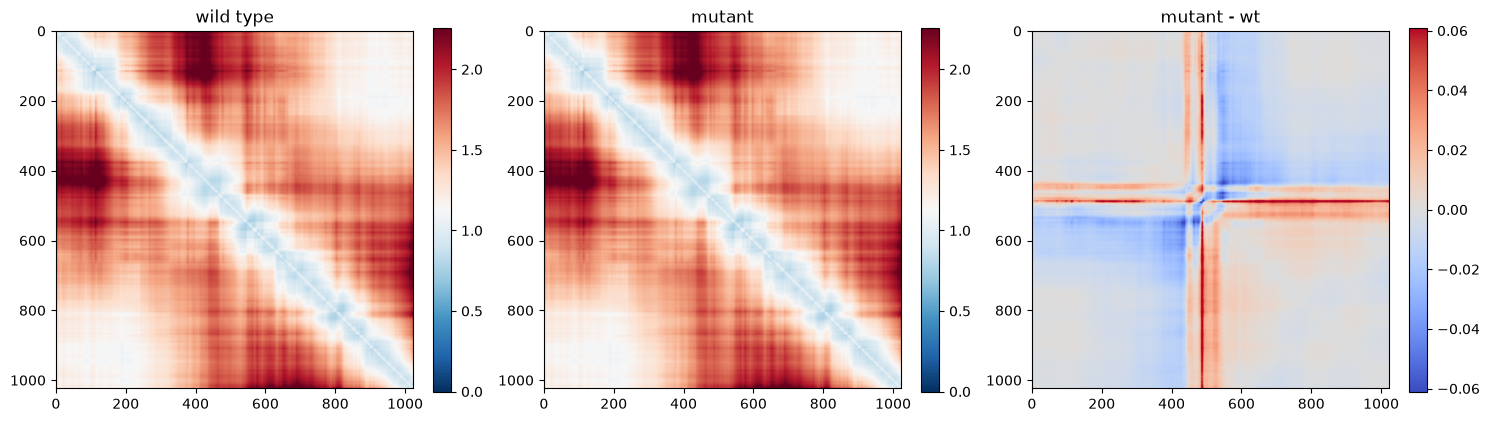

max |Δ|: 0.1548


In [6]:
import pysam
infer.fetcher.fasta_open = pysam.FastaFile(FASTA)   # mutations need a FASTA handle
mut = [("replace", start_bp + 2_000_000, "A" * 4000)]      # a 4 kb replacement inside the window
wt, mu = infer.predict_pair("chr1", start_bp, mut, n_runs=1, run_idx=RUN_IDX)
c = 0
W, M = wt[c].float().cpu().numpy(), mu[c].float().cpu().numpy(); D = M - W
vmax = np.nanpercentile(W, 99); dmax = np.nanpercentile(np.abs(D), 99.5)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, img, ttl, cm, kw in (
    (ax[0], W, "wild type", "RdBu_r", dict(vmin=0, vmax=vmax)),
    (ax[1], M, "mutant",    "RdBu_r", dict(vmin=0, vmax=vmax)),
    (ax[2], D, "mutant - wt","coolwarm", dict(vmin=-dmax, vmax=dmax)),
):
    im = a.imshow(img, cmap=cm, **kw); a.set_title(ttl); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
print("max |Δ|:", round(float(np.abs(D).max()), 4))

## 4. Explore training data without a model

`HiCDataset` samples eligible windows for a fold split. Use `sampling="strided"` for a reproducible tiling
(great for eval/plotting); `sampling="random"` draws `N_eligible // stride` random windows per epoch for
training. Here we just peek at validation-fold targets with a model-free stub fetcher.

train folds: [0, 1, 2, 5, 6, 7] | val: {3} | test: {4}
folds on chr1: [0, 1, 2, 3, 5, 7] -> sampling fold 0
strided fold-0 windows on chr1: 47


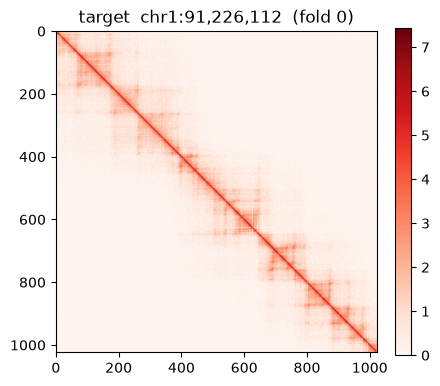

In [7]:
class _NoActs:
    def fetch(self, *a, **k):  # stand-in fetcher: we only want to look at targets here
        return None

# Genome-wide fold split (val=3, test=4, rest=train):
train_folds, val_folds, test_folds = train_val_test_folds(bf, val_fold=3, test_fold=4)
print("train folds:", sorted(train_folds), "| val:", val_folds, "| test:", test_folds)

# Borzoi folds are contiguous genome blocks, so a chromosome holds only some of them. The demo cache is
# chr1-only, so illustrate the sampler on a fold that actually occurs on chr1.
chr1_folds = sorted({int(f) for f in np.unique(bf.store("chr1").fold_id) if f >= 0})
demo_fold = chr1_folds[0]
print("folds on chr1:", chr1_folds, "-> sampling fold", demo_fold)

ds = HiCDataset(bf, _NoActs(), n_bins=N_BINS, bins_pad=128, folds={demo_fold},
                sampling="strided", chroms=["chr1"])
print("strided fold-%d windows on chr1:" % demo_fold, len(ds))
s = ds[len(ds) // 2]
plt.figure(figsize=(4.5, 4.5))
plt.imshow(np.log1p(s["hic_slice"][0]), cmap="Reds")
plt.title(f"target  {s['chrom']}:{s['map_start_bp']:,}  (fold {demo_fold})"); plt.colorbar(fraction=0.046)
plt.tight_layout(); plt.show()